<a href="https://colab.research.google.com/github/Roynelle/orion-consultancy-/blob/main/RBL_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded = files.upload()


Saving RBL.csv to RBL (2).csv


['.config', 'RBL.csv', 'RBL (1).csv', 'RBL (2).csv', 'sample_data']

In [9]:
import os
os.listdir()
import pandas as pd

df = pd.read_csv("RBL.csv")
df.columns


Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [15]:
df['Revenue'] = df['Revenue'].astype(int)
df['Weekend'] = df['Weekend'].astype(int)
df.columns = df.columns.str.strip()

# Filter the columns to encode, keeping only those that exist in the DataFrame
cols_to_encode = [col for col in ['Month', 'VisitorType'] if col in df.columns]
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

X = df.drop("Revenue", axis=1)
y = df["Revenue"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier()

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = [lr, dt, rf]
names = ["Logistic Regression", "Decision Tree", "Random Forest"]

for model, name in zip(models, names):
    y_pred = model.predict(X_test)

    print(name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("---------------")

Logistic Regression
Accuracy: 0.8698296836982968
Precision: 0.7419354838709677
Recall: 0.3357664233576642
F1 Score: 0.4623115577889447
---------------
Decision Tree
Accuracy: 0.856853203568532
Precision: 0.572139303482587
Recall: 0.559610705596107
F1 Score: 0.5658056580565806
---------------
Random Forest
Accuracy: 0.8933495539334956
Precision: 0.7450331125827815
Recall: 0.5474452554744526
F1 Score: 0.6311360448807855
---------------


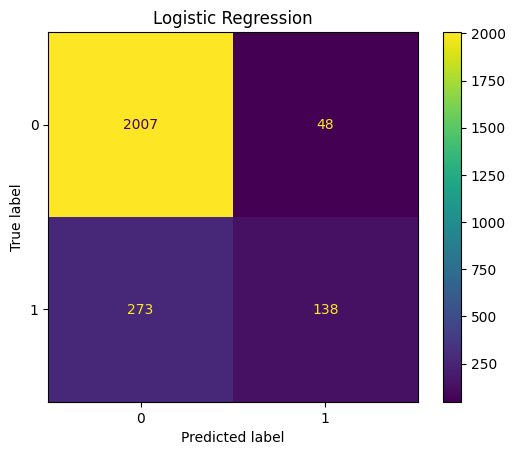

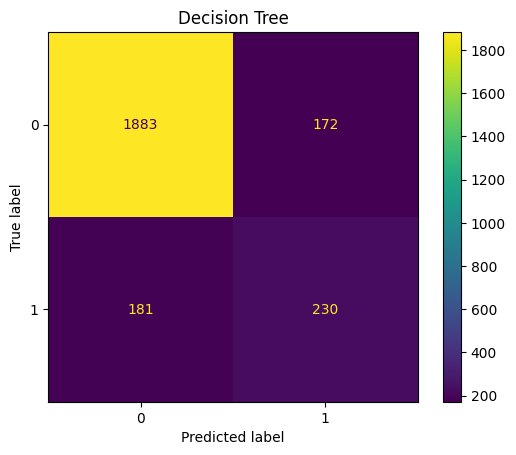

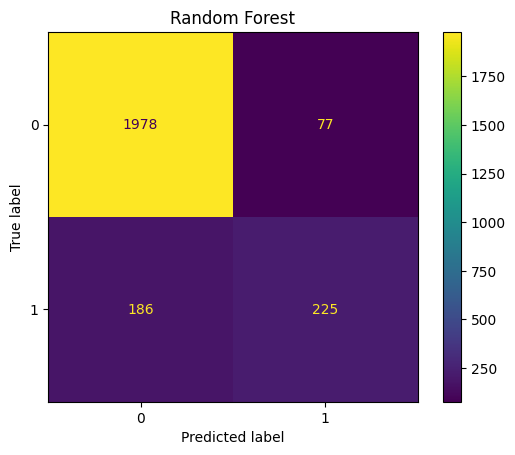

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = [lr, dt, rf]
names = ["Logistic Regression", "Decision Tree", "Random Forest"]

for model, name in zip(models, names):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)
    plt.show()